In [23]:
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt

IMAGE_PATH  = "dog.jpeg"
OUTPUT_JSON = "path.json"
TARGET_SIZE = 400  # alta resolução para preservar detalhes do contorno

## 1. Carregamento e Conversão para Escala de Cinza

Usa `cv2.imread` (único uso permitido) e converte manualmente com a fórmula de luminância perceptual:

$$Y = 0{,}114 \cdot B + 0{,}587 \cdot G + 0{,}299 \cdot R$$

Essa ponderação reflete a sensibilidade do olho humano a cada canal de cor.

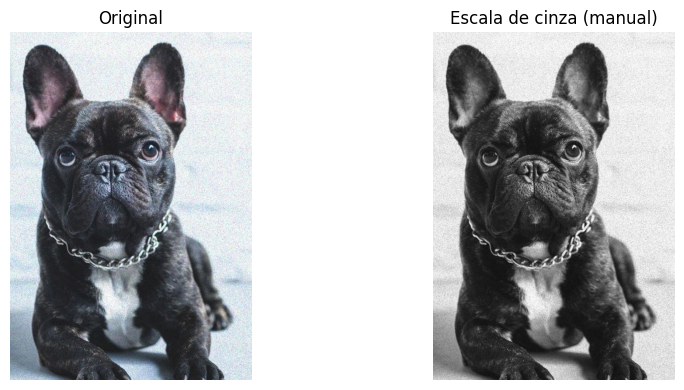

In [24]:
def load_image(path):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Imagem não encontrada: {path}")
    return img

def to_grayscale(bgr):
    """BGR → escala de cinza pela fórmula de luminância perceptual."""
    b = bgr[:, :, 0].astype(np.float64)
    g = bgr[:, :, 1].astype(np.float64)
    r = bgr[:, :, 2].astype(np.float64)
    gray = 0.114 * b + 0.587 * g + 0.299 * r
    return np.clip(gray, 0, 255).astype(np.uint8)

bgr  = load_image(IMAGE_PATH)
gray = to_grayscale(bgr)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[1].imshow(gray, cmap='gray')
axes[1].set_title("Escala de cinza (manual)")
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

## 2. Redimensionamento (Nearest-Neighbor)

Reduz para **200×200** antes de processar. Menos pixels = menos pontos de caminho no turtlesim.
Nearest-neighbor preserva bordas nítidas sem introduzir valores intermediários.

Tamanho original: (636, 441)  →  redimensionado: (400, 400)


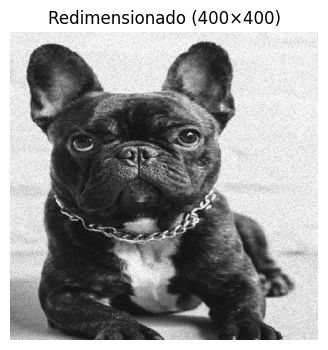

In [25]:
def resize_nearest(img, new_h, new_w):
    """Redimensionamento nearest-neighbor do zero via índices NumPy."""
    old_h, old_w = img.shape[:2]
    row_idx = (np.arange(new_h) * old_h / new_h).astype(int)
    col_idx = (np.arange(new_w) * old_w / new_w).astype(int)
    return img[np.ix_(row_idx, col_idx)]

small = resize_nearest(gray, TARGET_SIZE, TARGET_SIZE)
print(f"Tamanho original: {gray.shape}  →  redimensionado: {small.shape}")

plt.figure(figsize=(4, 4))
plt.imshow(small, cmap='gray')
plt.title(f"Redimensionado ({TARGET_SIZE}×{TARGET_SIZE})")
plt.axis('off')
plt.show()

## 3. Suavização Gaussiana

Filtro **5×5 com σ = 1,4** para remover ruído antes de derivar.
Sem suavização, o Sobel detectaria variações de textura como bordas falsas.

A convolução é vetorizada: em vez de iterar pixel a pixel (O(HW·k²)),
itera-se sobre os **k² = 25** elementos do kernel somando shifts NumPy.

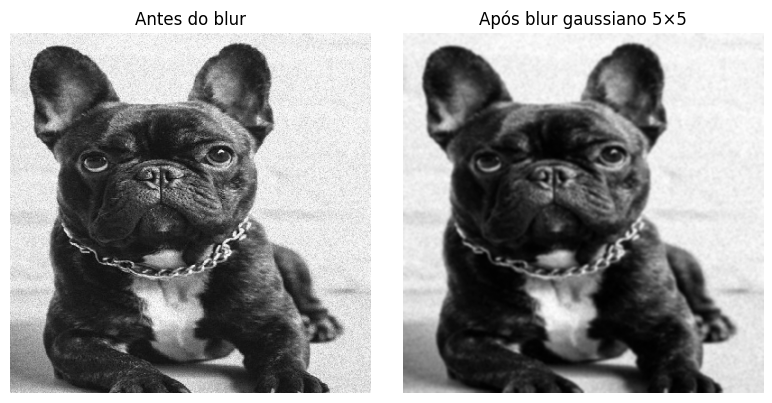

In [26]:
def gaussian_kernel(size, sigma):
    """Cria kernel gaussiano 2D do zero."""
    k = size // 2
    y, x = np.mgrid[-k:k+1, -k:k+1]
    kernel = np.exp(-(x**2 + y**2) / (2.0 * sigma**2))
    return kernel / kernel.sum()

def convolve2d(image, kernel):
    """Convolução 2D vetorizada — itera sobre o kernel, não sobre pixels."""
    ih, iw = image.shape
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    padded = np.pad(image.astype(np.float64),
                    ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect')
    output = np.zeros((ih, iw), dtype=np.float64)
    for ki in range(kh):
        for kj in range(kw):
            output += kernel[ki, kj] * padded[ki:ki+ih, kj:kj+iw]
    return output

def gaussian_blur(image, size=5, sigma=1.4):
    kernel  = gaussian_kernel(size, sigma)
    blurred = convolve2d(image, kernel)
    return np.clip(blurred, 0, 255).astype(np.uint8)

blurred = gaussian_blur(small, size=5, sigma=1.2)  # equilibrio entre suavidade e detalhe

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(small,   cmap='gray'); axes[0].set_title("Antes do blur")
axes[1].imshow(blurred, cmap='gray'); axes[1].set_title("Após blur gaussiano 5×5")
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Detecção de Bordas — Algoritmo de Canny (do zero)

### 4.1 Gradientes de Sobel
Os kernels de Sobel aproximam a derivada parcial em x e y:

$$|G| = \sqrt{G_x^2 + G_y^2} \qquad \theta = \text{atan2}(G_y, G_x)$$

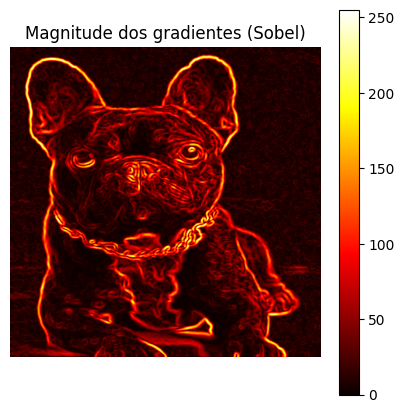

In [27]:
SOBEL_X = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=np.float64)

SOBEL_Y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]], dtype=np.float64)

def sobel_gradients(image):
    gx = convolve2d(image, SOBEL_X)
    gy = convolve2d(image, SOBEL_Y)
    magnitude = np.sqrt(gx**2 + gy**2)
    magnitude = magnitude / magnitude.max() * 255.0
    angle = np.arctan2(gy, gx) * 180.0 / np.pi % 180
    return magnitude, angle

magnitude, angle = sobel_gradients(blurred)

plt.figure(figsize=(5, 5))
plt.imshow(magnitude, cmap='hot')
plt.title("Magnitude dos gradientes (Sobel)")
plt.colorbar()
plt.axis('off')
plt.show()

### 4.2 Supressão de Não-Máximos

Cada pixel só é mantido se for o **máximo local** na direção do gradiente.
Isso afina as bordas para **1 pixel de espessura**.

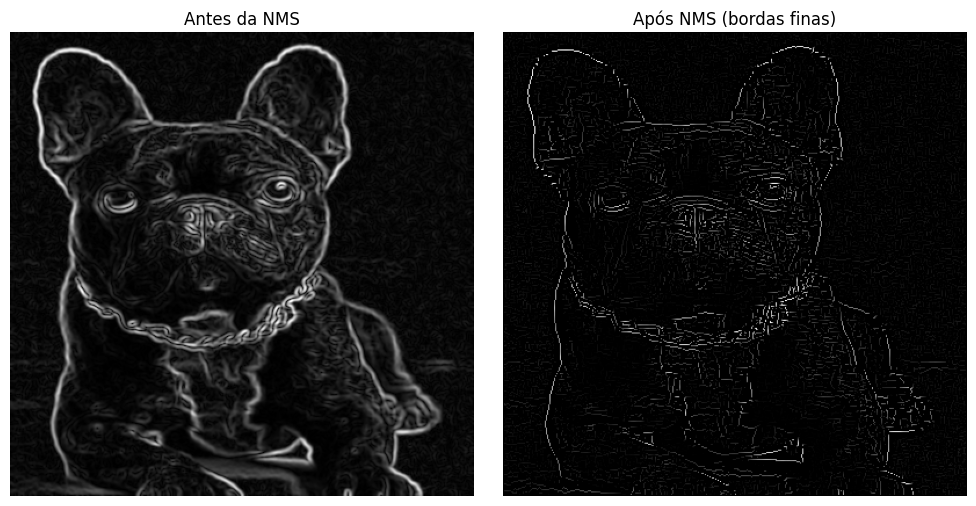

In [28]:
def non_maximum_suppression(magnitude, angle):
    h, w = magnitude.shape
    result = np.zeros_like(magnitude)
    for i in range(1, h-1):
        for j in range(1, w-1):
            a = angle[i, j]
            if   (0 <= a < 22.5) or (157.5 <= a <= 180): q, r = magnitude[i, j+1], magnitude[i, j-1]
            elif  22.5 <= a < 67.5:  q, r = magnitude[i+1, j-1], magnitude[i-1, j+1]
            elif  67.5 <= a < 112.5: q, r = magnitude[i+1, j],   magnitude[i-1, j]
            else:                    q, r = magnitude[i-1, j-1], magnitude[i+1, j+1]
            if magnitude[i, j] >= q and magnitude[i, j] >= r:
                result[i, j] = magnitude[i, j]
    return result

thin = non_maximum_suppression(magnitude, angle)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(magnitude, cmap='gray'); axes[0].set_title("Antes da NMS")
axes[1].imshow(thin,      cmap='gray'); axes[1].set_title("Após NMS (bordas finas)")
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

### 4.3 Limiar Duplo + Histerese

- **Limiar alto (15%)** → bordas fortes  
- **Limiar baixo (5%)** → bordas fracas candidatas  
- **Histerese**: mantém pixel fraco apenas se adjacente a um forte (8-conectividade)

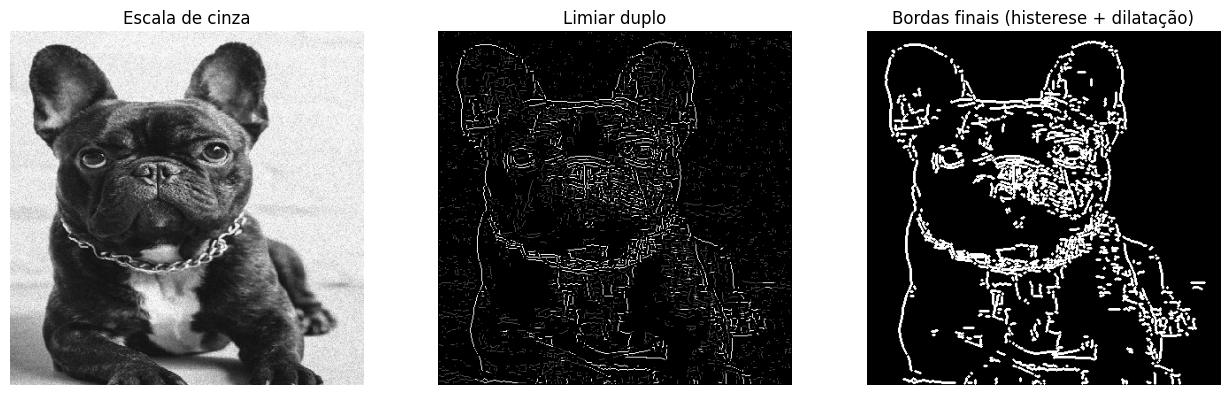

Bordas detectadas: 20282 pixels


In [ ]:
def double_threshold(image, low_ratio=0.08, high_ratio=0.22):

    high = image.max() * high_ratio
    low  = image.max() * low_ratio
    strong_val, weak_val = 255, 75
    result = np.zeros_like(image, dtype=np.uint8)
    result[image >= high] = strong_val
    result[(image >= low) & (image < high)] = weak_val
    return result, strong_val, weak_val

def hysteresis(image, strong=255, weak=75):
    h, w = image.shape
    result = image.copy()
    for i in range(1, h-1):
        for j in range(1, w-1):
            if result[i, j] == weak:
                if strong in result[i-1:i+2, j-1:j+2]:
                    result[i, j] = strong
                else:
                    result[i, j] = 0
    return result

def dilate(image, radius=1):
    
    h, w = image.shape
    result = np.zeros_like(image)
    for di in range(-radius, radius+1):
        for dj in range(-radius, radius+1):
            if di**2 + dj**2 <= radius**2:
                shifted = np.roll(np.roll(image, di, axis=0), dj, axis=1)
                result = np.maximum(result, shifted)
    return result

thresh, strong, weak = double_threshold(thin, low_ratio=0.07, high_ratio=0.20)
edges = hysteresis(thresh, strong, weak)
edges = dilate(edges, radius=1)  # fecha buracos pequenos

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(small,  cmap='gray'); axes[0].set_title("Escala de cinza")
axes[1].imshow(thresh, cmap='gray'); axes[1].set_title("Limiar duplo")
axes[2].imshow(edges,  cmap='gray'); axes[2].set_title("Bordas finais (histerese + dilatação)")
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.savefig("edges_result.png", dpi=120)
plt.show()
print(f"Bordas detectadas: {(edges == 255).sum()} pixels")

## 5. Planejamento de Caminho

Extrai os pixels de borda e os ordena por **greedy nearest-neighbor**:
parte de um ponto e avança sempre para o vizinho não visitado mais próximo.
Quando o salto supera `max_gap`, insere `None` (levanta a caneta no turtlesim).

In [ ]:
def extract_edge_points(edges):
    rows, cols = np.where(edges == 255)
    return np.column_stack((rows, cols))

def label_components(edges):
    
    visited = np.zeros_like(edges, dtype=bool)
    h, w = edges.shape
    dirs = [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]
    components = []

    edge_rows, edge_cols = np.where(edges == 255)
    for sr, sc in zip(edge_rows, edge_cols):
        if visited[sr, sc]:
            continue
        # BFS para coletar componente
        comp = []
        queue = [(sr, sc)]
        visited[sr, sc] = True
        while queue:
            r, c = queue.pop()
            comp.append((r, c))
            for dr, dc in dirs:
                nr, nc = r+dr, c+dc
                if 0 <= nr < h and 0 <= nc < w and edges[nr,nc]==255 and not visited[nr,nc]:
                    visited[nr,nc] = True
                    queue.append((nr,nc))
        components.append(comp)
    return components

def chain_trace_component(comp, edges):
    
    h, w = edges.shape
    dirs = [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]
    visited_local = set()
    path = []
    start = comp[0]
    r, c = start
    while True:
        if (r,c) in visited_local:
            break
        visited_local.add((r,c))
        path.append((r,c))
        found = False
        for dr, dc in dirs:
            nr, nc = r+dr, c+dc
            if (nr,nc) in set(comp) - visited_local:
                r, c = nr, nc
                found = True
                break
        if not found:
            break
    return path

def build_path(edges, connect_gap=8.0):
    
    components = label_components(edges)

    # Descarta componentes com menos de 5 pixels (ruído)
    components = [c for c in components if len(c) >= 5]
    print(f"  Componentes após filtro: {len(components)}")

    if not components:
        return []

    # Ordena componentes por proximidade (greedy entre componentes)
    remaining = list(range(len(components)))
    ordered_comps = [remaining.pop(0)]
    while remaining:
        last_pt = components[ordered_comps[-1]][-1]
        best_i, best_d = None, np.inf
        for i in remaining:
            first_pt = components[i][0]
            d = np.sqrt((last_pt[0]-first_pt[0])**2 + (last_pt[1]-first_pt[1])**2)
            if d < best_d:
                best_d, best_i = d, i
        ordered_comps.append(best_i)
        remaining.remove(best_i)

    # Monta caminho final
    path = []
    for ci in ordered_comps:
        comp = components[ci]
        if path:
            last = path[-1] if path[-1] is not None else None
            if last is not None:
                d = np.sqrt((last[0]-comp[0][0])**2 + (last[1]-comp[0][1])**2)
                if d > connect_gap:
                    path.append(None)  # só levanta se realmente longe
        path.extend(comp)

    return path

print("Rastreando contornos e conectando componentes...")
ordered = build_path(edges, connect_gap=8.0)
n_gaps = sum(1 for p in ordered if p is None)
n_pts  = sum(1 for p in ordered if p is not None)
print(f"Pontos de desenho: {n_pts}  |  Cortes (caneta levantada): {n_gaps}")

Rastreando contornos e conectando componentes...
  Componentes após filtro: 236
Pontos de desenho: 20282  |  Cortes (caneta levantada): 172


## 6. Mapeamento para o Espaço do Turtlesim

O turtlesim usa coordenadas `[0, 11]`, origem no canto **inferior esquerdo**.
Pixels têm origem no canto **superior esquerdo**, então o eixo Y precisa ser invertido:

$$x_{ts} = 1{,}0 + \frac{col}{N-1} \cdot 9{,}0 \qquad y_{ts} = 10{,}0 - \frac{row}{N-1} \cdot 9{,}0$$

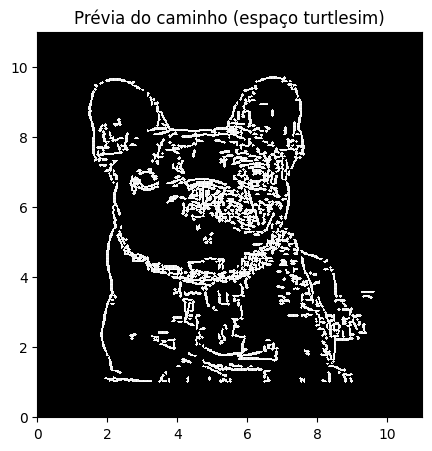

In [31]:
def map_to_turtlesim(path, img_h, img_w, ts_min=1.0, ts_max=10.0):
    mapped = []
    for pt in path:
        if pt is None:
            mapped.append(None)
        else:
            row, col = pt
            x = ts_min + (col / (img_w - 1)) * (ts_max - ts_min)
            y = ts_max - (row / (img_h - 1)) * (ts_max - ts_min)  # inverte Y
            mapped.append((round(x, 4), round(y, 4)))
    return mapped

ts_path = map_to_turtlesim(ordered, TARGET_SIZE, TARGET_SIZE)

# Visualiza o caminho mapeado
xs = [p[0] for p in ts_path if p is not None]
ys = [p[1] for p in ts_path if p is not None]
plt.figure(figsize=(5, 5))
plt.scatter(xs, ys, s=0.5, c='white', linewidths=0)
plt.gca().set_facecolor('black')
plt.gca().set_aspect('equal')
plt.title("Prévia do caminho (espaço turtlesim)")
plt.xlim(0, 11); plt.ylim(0, 11)
plt.show()

## 7. Exportar `path.json`

Salva o caminho como JSON para ser lido pelo nó ROS 2 `turtle_node.py`.

In [32]:
serializable = [list(p) if p is not None else None for p in ts_path]

with open(OUTPUT_JSON, "w") as f:
    json.dump(serializable, f)

print(f"Caminho salvo em '{OUTPUT_JSON}'")
print(f"Total de entradas: {len(serializable)}")
print(f"Pontos de desenho: {sum(1 for p in serializable if p is not None)}")
print(f"Saltos (caneta levantada): {sum(1 for p in serializable if p is None)}")

Caminho salvo em 'path.json'
Total de entradas: 20454
Pontos de desenho: 20282
Saltos (caneta levantada): 172
